## Setup

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, f1_score

%matplotlib inline

## Prepare training data

In [19]:
OUTPUT_COLUMN = 'Slow'
TARGET_COLUMN = 'router_speedtest_tcp_64_download_Mbps_avg'

tree_df = pd.read_csv('data/processed/tree/tree_df.csv')
tree_df['link_failure_detected'] = tree_df['link_failure_detected'].astype('category')
print(f'tree_df shape: {tree_df.shape}')
print (tree_df.dtypes.value_counts())

# Prepare train and val sets
X = tree_df.drop(columns=[OUTPUT_COLUMN])
y = tree_df[OUTPUT_COLUMN].astype(int)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=0, stratify=y)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')

tree_df shape: (61160, 40)
float64     35
int64        3
category     1
bool         1
Name: count, dtype: int64
Train: (55044, 39), Val: (6116, 39)


## Prepare holdout data

In [ ]:
# Load holdout and data_engineering artifacts
holdout_df = pd.read_csv('data/raw/holdout.csv')
gateway_site_keys = pickle.load(open('gateway_site_keys.pkl', 'rb'))
running_tables = pickle.load(open('running_tables.pkl', 'rb'))
running_tables_2 = pickle.load(open('running_tables_2.pkl', 'rb'))
global_fallbacks = pickle.load(open('global_fallbacks.pkl', 'rb'))

TIME_COLUMN = 'slot_timestamp'

# Fix dtypes (same as data_engineering)
numToStr = ['cell_id','home_pop_id','gateway_id','satellite_id', 'ku_beam_target_cell_id']
for colName in numToStr:
    holdout_df[colName] = holdout_df[colName].astype(str)

# Clean link_failure_detected (same as data_engineering cell-7)
holdout_df['link_failure_detected'] = holdout_df['link_failure_detected'].fillna('Unknown').astype(str)

# Merge gateway_site_id
holdout_df = holdout_df.merge(gateway_site_keys, on='gateway_id', how='left')

# Create beam_pct_allocation
holdout_df['beam_pct_allocation'] = 1 / (holdout_df['number_of_ku_beam_targets'] * holdout_df['number_of_users_on_ku_beam_target'])

# Convert timestamp to datetime and sort
holdout_df[TIME_COLUMN] = pd.to_datetime(holdout_df[TIME_COLUMN])
holdout_df = holdout_df.sort_values(TIME_COLUMN)

# Merge speed running tables via merge_asof (backward lookup by key)
speed_keys = ['cell_id', 'ku_beam_target_cell_id', 'home_pop_id', 'satellite_id', 
              'gateway_id', 'gateway_site_id', 'country_code']
for key in speed_keys:
    rt = running_tables[key].copy()
    rt[TIME_COLUMN] = pd.to_datetime(rt[TIME_COLUMN])
    rt = rt.sort_values(TIME_COLUMN)
    holdout_df = holdout_df.sort_values(TIME_COLUMN)
    holdout_df = pd.merge_asof(
        holdout_df,
        rt,
        on=TIME_COLUMN,
        by=key,
        direction='backward'
    )
    holdout_df[f'median_speed_{key}'] = holdout_df[f'median_speed_{key}'].fillna(global_fallbacks['global_median_speed'])
    holdout_df[f'pct_slow_{key}'] = holdout_df[f'pct_slow_{key}'].fillna(global_fallbacks['global_pct_slow'])

# Merge gateway running tables via merge_asof
gateway_keys = ['gateway_id', 'satellite_id', 'gateway_site_id']
for key in gateway_keys:
    rt = running_tables_2[key].copy()
    rt['slot_timestamp'] = pd.to_datetime(rt['slot_timestamp'])
    rt = rt.sort_values('slot_timestamp')
    holdout_df = holdout_df.sort_values(TIME_COLUMN)
    holdout_df = pd.merge_asof(
        holdout_df,
        rt,
        left_on=TIME_COLUMN,
        right_on='slot_timestamp',
        by=key,
        direction='backward'
    )
    if 'slot_timestamp_y' in holdout_df.columns:
        holdout_df = holdout_df.drop(columns=['slot_timestamp_y'])
    if 'slot_timestamp_x' in holdout_df.columns:
        holdout_df = holdout_df.rename(columns={'slot_timestamp_x': TIME_COLUMN})

# Fill NaN gateway features with column medians
gateway_agg_names = ['median_users', 'median_ka_beam_avg_util_percent', 
                     'p95_ka_beam_max_util_percent', 'p100_ka_beam_max_util_percent',
                     'avg_ka_beam_active_count']
for key in gateway_keys:
    for feat in gateway_agg_names:
        col = f'{feat}_{key}'
        if col in holdout_df.columns:
            holdout_df[col] = holdout_df[col].fillna(holdout_df[col].median())

# Extract holdout target before dropping columns
y_holdout = holdout_df[OUTPUT_COLUMN].astype(int)

# Drop ID columns + timestamp
holdout_df = holdout_df.drop(columns=[
    'gateway_id', 'satellite_id', 'gateway_site_id', TIME_COLUMN,
    'cell_id', 'home_pop_id', 'ku_beam_target_cell_id', 'country_code', 'test_id'
], errors='ignore')

# Match category dtype from training set
holdout_df['link_failure_detected'] = holdout_df['link_failure_detected'].astype('category')

# Drop output column to get features only
X_holdout = holdout_df.drop(columns=[OUTPUT_COLUMN])

# Align columns with training set (handle any missing/extra dummy columns)
for col in X_train.columns:
    if col not in X_holdout.columns:
        X_holdout[col] = 0
X_holdout = X_holdout[X_train.columns]

print(f'Holdout: {X_holdout.shape}, target balance: {y_holdout.mean():.3f}')
print(f'Columns match training: {list(X_holdout.columns) == list(X_train.columns)}')

## Modeling

In [ ]:
model = XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    random_state=1,
    scale_pos_weight=1,
    early_stopping_rounds=20,
    enable_categorical=True
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=10)

# Evaluate on validation set
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba > 0.5).astype(int)
val_pr_auc = average_precision_score(y_val, y_val_proba)
val_f1 = f1_score(y_val, y_val_pred)

y_train_pred = model.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

print(classification_report(y_val, y_val_pred))
print(f'Train F1 (Slow): {train_f1:.4f}')
print(f'Val F1 (Slow): {val_f1:.4f}')
print(f'Val PR-AUC: {val_pr_auc:.4f}')

Top 15 features:
  number_of_users_on_ku_beam                    0.1334
  median_speed_cell_id                          0.1208
  ut_latency                                    0.1076
  ut_snr                                        0.0737
  beam_pct_allocation                           0.0653
  pct_slow_cell_id                              0.0479
  median_speed_ku_beam_target_cell_id           0.0293
  ut_ping_loss_rate                             0.0262
  number_of_ku_beam_targets                     0.0190
  link_failure_detected                         0.0189
  number_of_users_on_ku_beam_target             0.0178
  pct_slow_ku_beam_target_cell_id               0.0164
  pct_slow_gateway_site_id                      0.0154
  median_speed_country_code                     0.0151
  median_speed_gateway_site_id                  0.0143


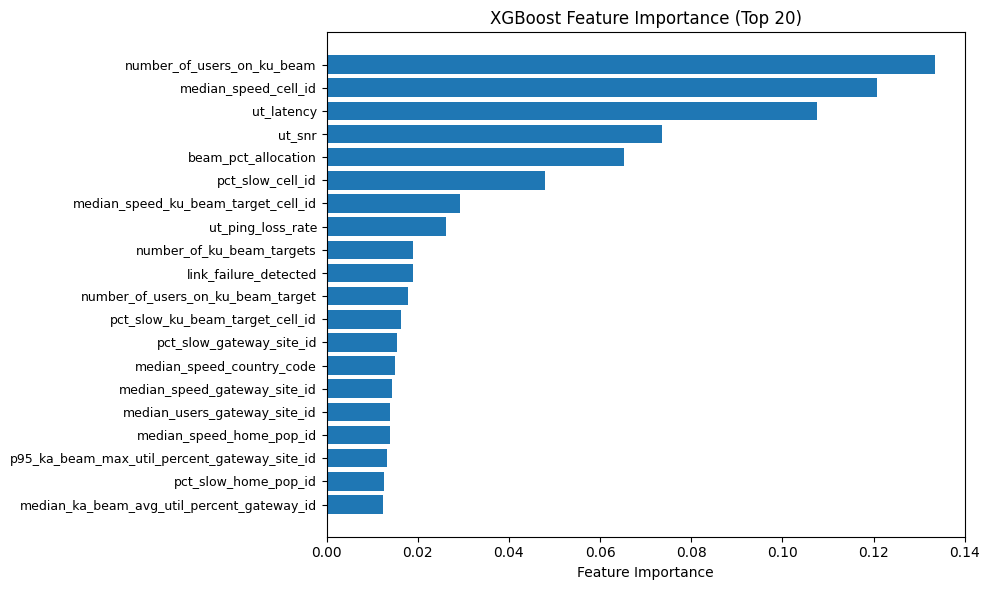

In [25]:
# Feature importance
feature_importance = model.feature_importances_
feature_names = X_train.columns

sorted_features = sorted(zip(feature_names, feature_importance), key=lambda x: x[1], reverse=True)

print('Top 15 features:')
for name, imp in sorted_features[:15]:
    print(f'  {name:45s} {imp:.4f}')

# Plot
top_n = 20
names, imps = zip(*sorted_features[:top_n])
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_n), imps[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(names[::-1], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance (Top 20)')
plt.tight_layout()

In [ ]:
# Evaluate on holdout set
y_holdout_proba = model.predict_proba(X_holdout)[:, 1]
y_holdout_pred = (y_holdout_proba > 0.5).astype(int)
holdout_pr_auc = average_precision_score(y_holdout, y_holdout_proba)
holdout_f1 = f1_score(y_holdout, y_holdout_pred)

print('--- Holdout Results ---')
print(classification_report(y_holdout, y_holdout_pred))
print(f'Holdout F1 (Slow): {holdout_f1:.4f}')
print(f'Holdout PR-AUC: {holdout_pr_auc:.4f}')

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_holdout, y_holdout_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Holdout Precision-Recall Curve (PR-AUC={holdout_pr_auc:.4f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [ ]:
# Save model
model.save_model('xgboost_model.json')
print('Model saved to xgboost_model.json')

## PCA-based models (Logistic Regression, SVM, MLP)

In [ ]:
# Load PCA data and artifacts
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

pca_df = pd.read_csv('data/processed/pca_df.csv')
pca_scaler = pickle.load(open('pca_scaler.pkl', 'rb'))
pca_model = pickle.load(open('pca_model.pkl', 'rb'))

X_pca = pca_df.drop(columns=[OUTPUT_COLUMN])
y_pca = pca_df[OUTPUT_COLUMN].astype(int)

X_pca_train, X_pca_val, y_pca_train, y_pca_val = train_test_split(
    X_pca, y_pca, test_size=0.1, random_state=0, stratify=y_pca
)
print(f'PCA Train: {X_pca_train.shape}, Val: {X_pca_val.shape}')
print(f'Class balance — train: {y_pca_train.mean():.3f}, val: {y_pca_val.mean():.3f}')

In [ ]:
# Logistic Regression
from sklearn.linear_model import SGDClassifier

lr_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=0)
lr_model.fit(X_pca_train, y_pca_train)

y_lr_val_pred = lr_model.predict(X_pca_val)
y_lr_val_proba = lr_model.decision_function(X_pca_val)
lr_val_pr_auc = average_precision_score(y_pca_val, y_lr_val_proba)
lr_val_f1 = f1_score(y_pca_val, y_lr_val_pred)
lr_train_f1 = f1_score(y_pca_train, lr_model.predict(X_pca_train))

print('--- Logistic Regression (SGD): Validation Results ---')
print(classification_report(y_pca_val, y_lr_val_pred))
print(f'Train F1 (Slow): {lr_train_f1:.4f}')
print(f'Val F1 (Slow): {lr_val_f1:.4f}')
print(f'Val PR-AUC: {lr_val_pr_auc:.4f}')

In [ ]:
# SVM via SGD (linear kernel — RBF SVC is too slow for this dataset size)
svm_model = SGDClassifier(loss='hinge', max_iter=1000, random_state=0)
svm_model.fit(X_pca_train, y_pca_train)

y_svm_val_pred = svm_model.predict(X_pca_val)
y_svm_val_proba = svm_model.decision_function(X_pca_val)
svm_val_pr_auc = average_precision_score(y_pca_val, y_svm_val_proba)
svm_val_f1 = f1_score(y_pca_val, y_svm_val_pred)
svm_train_f1 = f1_score(y_pca_train, svm_model.predict(X_pca_train))

print('--- SVM (Linear SGD): Validation Results ---')
print(classification_report(y_pca_val, y_svm_val_pred))
print(f'Train F1 (Slow): {svm_train_f1:.4f}')
print(f'Val F1 (Slow): {svm_val_f1:.4f}')
print(f'Val PR-AUC: {svm_val_pr_auc:.4f}')

In [ ]:
# MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=0, early_stopping=True)
mlp_model.fit(X_pca_train, y_pca_train)

y_mlp_val_pred = (mlp_model.predict_proba(X_pca_val)[:, 1] > 0.5).astype(int)
y_mlp_val_proba = mlp_model.predict_proba(X_pca_val)[:, 1]
mlp_val_pr_auc = average_precision_score(y_pca_val, y_mlp_val_proba)
mlp_val_f1 = f1_score(y_pca_val, y_mlp_val_pred)
mlp_train_f1 = f1_score(y_pca_train, mlp_model.predict(X_pca_train))

print('--- MLP: Validation Results ---')
print(classification_report(y_pca_val, y_mlp_val_pred))
print(f'Train F1 (Slow): {mlp_train_f1:.4f}')
print(f'Val F1 (Slow): {mlp_val_f1:.4f}')
print(f'Val PR-AUC: {mlp_val_pr_auc:.4f}')

In [ ]:
# Prepare PCA holdout data — transform holdout features through the same scaler + PCA
X_holdout_pca_raw = X_holdout.copy()
X_holdout_pca_raw = pd.get_dummies(X_holdout_pca_raw, columns=['link_failure_detected'], drop_first=False, dtype='int64')

# Align columns with what pca_scaler was fit on
pca_feature_cols = [c for c in pd.get_dummies(
    tree_df.drop(columns=[OUTPUT_COLUMN]),
    columns=['link_failure_detected'], drop_first=False, dtype='int64'
).columns]
for col in pca_feature_cols:
    if col not in X_holdout_pca_raw.columns:
        X_holdout_pca_raw[col] = 0
X_holdout_pca_raw = X_holdout_pca_raw[pca_feature_cols]

# Fill any remaining NaN with column medians from training data
train_medians = pd.get_dummies(
    tree_df.drop(columns=[OUTPUT_COLUMN]),
    columns=['link_failure_detected'], drop_first=False, dtype='int64'
).median()
X_holdout_pca_raw = X_holdout_pca_raw.fillna(train_medians)

X_holdout_scaled = pca_scaler.transform(X_holdout_pca_raw)
X_holdout_pca = pca_model.transform(X_holdout_scaled)

# Evaluate all PCA models on holdout
y_lr_holdout_pred = lr_model.predict(X_holdout_pca)
y_lr_holdout_proba = lr_model.decision_function(X_holdout_pca)
lr_holdout_pr_auc = average_precision_score(y_holdout, y_lr_holdout_proba)
lr_holdout_f1 = f1_score(y_holdout, y_lr_holdout_pred)
print(f'Logistic Regression — Holdout F1 (Slow): {lr_holdout_f1:.4f}, PR-AUC: {lr_holdout_pr_auc:.4f}')
print(classification_report(y_holdout, y_lr_holdout_pred))

y_svm_holdout_pred = svm_model.predict(X_holdout_pca)
y_svm_holdout_proba = svm_model.decision_function(X_holdout_pca)
svm_holdout_pr_auc = average_precision_score(y_holdout, y_svm_holdout_proba)
svm_holdout_f1 = f1_score(y_holdout, y_svm_holdout_pred)
print(f'SVM — Holdout F1 (Slow): {svm_holdout_f1:.4f}, PR-AUC: {svm_holdout_pr_auc:.4f}')
print(classification_report(y_holdout, y_svm_holdout_pred))

y_mlp_holdout_proba = mlp_model.predict_proba(X_holdout_pca)[:, 1]
y_mlp_holdout_pred = (y_mlp_holdout_proba > 0.5).astype(int)
mlp_holdout_pr_auc = average_precision_score(y_holdout, y_mlp_holdout_proba)
mlp_holdout_f1 = f1_score(y_holdout, y_mlp_holdout_pred)
print(f'MLP — Holdout F1 (Slow): {mlp_holdout_f1:.4f}, PR-AUC: {mlp_holdout_pr_auc:.4f}')
print(classification_report(y_holdout, y_mlp_holdout_pred))

In [ ]:
# Model comparison summary — F1 for positive class (Slow=1)
results = pd.DataFrame({
    'Model': ['XGBoost (tree features)', 'Logistic Regression SGD (PCA)', 'SVM Linear SGD (PCA)', 'MLP (PCA)'],
    'Train F1': [train_f1, lr_train_f1, svm_train_f1, mlp_train_f1],
    'Val F1': [val_f1, lr_val_f1, svm_val_f1, mlp_val_f1],
    'Holdout F1': [holdout_f1, lr_holdout_f1, svm_holdout_f1, mlp_holdout_f1],
    'Holdout PR-AUC': [holdout_pr_auc, lr_holdout_pr_auc, svm_holdout_pr_auc, mlp_holdout_pr_auc],
})
print(results.to_string(index=False))